# RNN: Recurrent Neural Networks

## Gradient Dynamics, BPTT, LSTM, GRU, PyTorch/JAX Implementations, and the Bridge to Attention

This notebook addresses the concept of the Recurrent neural networks. It starts from linear layers and dynamical systems, derives recurrent neural networks mathematically, proves why vanishing and exploding gradients occur, explains LSTM/GRU as structural remedies, and ends by connecting recurrence to attention mechanisms.

### Learning goals

By the end, you should be able to:

1. Derive a vanilla RNN from affine transformations and shared parameters.
2. Interpret an RNN as both an unrolled deep network and a nonlinear dynamical system.
3. Derive Backpropagation Through Time (BPTT) using Jacobian products.
4. Prove exponential vanishing/explosion using norm bounds and spectral radius arguments.
5. Explain why tanh/sigmoid saturation worsens gradient decay.
6. Implement RNNs manually and using `torch.nn.RNN`.
7. Derive LSTM and GRU update equations step by step.
8. Explain the LSTM cell-state gradient path mathematically.
9. Use gradient clipping, orthogonal initialization, and truncated BPTT.
10. Understand attention as direct memory access and a conceptual successor to recurrence.


## 1. Why sequence models are different

Many machine-learning problems are sequential:

- language modeling,
- speech recognition,
- machine translation,
- time-series forecasting,
- video analysis,
- control systems,
- event streams,
- biological sequences.

A feedforward model maps an input $x$ to an output $y$ independently:

$$
y = f_\theta(x).
$$

A sequence model receives ordered inputs:

$$
x_1, x_2, \ldots, x_T.
$$

The output at time $t$ may depend not only on $x_t$, but on the entire past:

$$
y_t = f_\theta(x_1, x_2, \ldots, x_t).
$$

The central challenge is therefore **memory**. A recurrent model introduces a hidden state $h_t$ that summarizes past information:

$$
h_t = \text{summary of } (x_1, \ldots, x_t).
$$

This hidden state is updated sequentially, which gives the model an inductive bias for temporal structure.


## 2. From a linear layer to recurrence

A standard linear layer is

$$
z = Wx + b.
$$

A one-hidden-layer neural network is

$$
h = \phi(Wx + b),
$$

where $\phi$ is a nonlinearity such as $\tanh$, ReLU, or sigmoid.

For sequences, we want the hidden representation at time $t$ to depend on:

1. the current input $x_t$,
2. the previous hidden state $h_{t-1}$.

So the simplest recurrent update is

$$
a_t = W_x x_t + W_h h_{t-1} + b_h,
$$

$$
h_t = \phi(a_t).
$$

The output is often computed as

$$
o_t = W_y h_t + b_y,
$$

$$
y_t = g(o_t),
$$

where $g$ may be softmax for classification or identity for regression.

### Parameter shapes

Let:

- $x_t \in \mathbb{R}^{d_x}$,
- $h_t \in \mathbb{R}^{d_h}$,
- $y_t \in \mathbb{R}^{d_y}$.

Then:

$$
W_x \in \mathbb{R}^{d_h \times d_x}, \qquad
W_h \in \mathbb{R}^{d_h \times d_h}, \qquad
W_y \in \mathbb{R}^{d_y \times d_h}.
$$

The important conceptual point is that $W_x$, $W_h$, and $W_y$ are shared across all time steps. This parameter sharing is what makes the model recurrent rather than merely deep.


## 3. RNN computation graph

The same cell is reused at every time step.


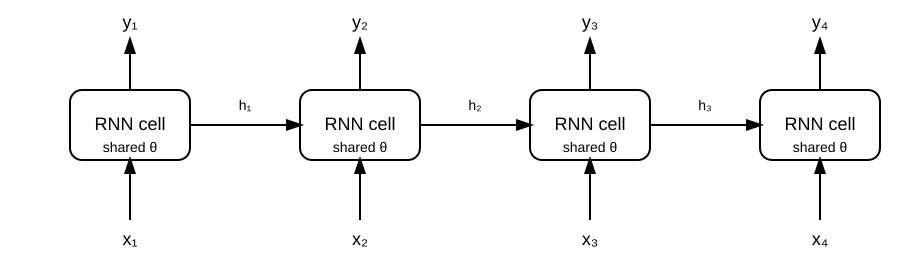

In [3]:
from IPython.display import SVG, display

svg = r'''<svg width="900" height="270" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black" />
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 12; }
    .txt { font-family: Arial, sans-serif; font-size: 18px; text-anchor: middle; }
    .small { font-family: Arial, sans-serif; font-size: 14px; text-anchor: middle; }
    .line { stroke: black; stroke-width: 2; marker-end: url(#arrow); fill: none; }
  </style>
  <rect x="70" y="90" width="120" height="70" class="box" />
  <text x="130" y="130" class="txt">RNN cell</text>
  <text x="130" y="152" class="small">shared θ</text>

  <rect x="300" y="90" width="120" height="70" class="box" />
  <text x="360" y="130" class="txt">RNN cell</text>
  <text x="360" y="152" class="small">shared θ</text>

  <rect x="530" y="90" width="120" height="70" class="box" />
  <text x="590" y="130" class="txt">RNN cell</text>
  <text x="590" y="152" class="small">shared θ</text>

  <rect x="760" y="90" width="120" height="70" class="box" />
  <text x="820" y="130" class="txt">RNN cell</text>
  <text x="820" y="152" class="small">shared θ</text>

  <path d="M190 125 L300 125" class="line" />
  <path d="M420 125 L530 125" class="line" />
  <path d="M650 125 L760 125" class="line" />

  <path d="M130 220 L130 160" class="line" />
  <path d="M360 220 L360 160" class="line" />
  <path d="M590 220 L590 160" class="line" />
  <path d="M820 220 L820 160" class="line" />

  <text x="130" y="245" class="txt">x₁</text>
  <text x="360" y="245" class="txt">x₂</text>
  <text x="590" y="245" class="txt">x₃</text>
  <text x="820" y="245" class="txt">x₄</text>

  <path d="M130 90 L130 40" class="line" />
  <path d="M360 90 L360 40" class="line" />
  <path d="M590 90 L590 40" class="line" />
  <path d="M820 90 L820 40" class="line" />

  <text x="130" y="28" class="txt">y₁</text>
  <text x="360" y="28" class="txt">y₂</text>
  <text x="590" y="28" class="txt">y₃</text>
  <text x="820" y="28" class="txt">y₄</text>

  <text x="245" y="110" class="small">h₁</text>
  <text x="475" y="110" class="small">h₂</text>
  <text x="705" y="110" class="small">h₃</text>
</svg>'''

display(SVG(svg))



The horizontal arrows carry hidden states. The vertical arrows inject inputs and produce outputs.


## 4. Sequence loss and sequence-to-sequence mapping types

A recurrent model can be used in several different input/output configurations. The recurrence itself is usually the same:

$$
h_t = F_\theta(h_{t-1}, x_t),
$$

but the **loss function changes depending on which hidden states are connected to supervised outputs**.

A useful general expression is:

$$
\mathcal{L}
=
\sum_{t \in \mathcal{T}_{\text{loss}}}
\ell_t(y_t, \hat{y}_t),
$$

where $\mathcal{T}_{\text{loss}}$ is the set of time steps at which the model is supervised.


### 4.1 Many-to-many, aligned / synchronous prediction

In aligned many-to-many prediction, the model produces an output at every input time step.

Typical examples:

- part-of-speech tagging,
- named-entity recognition,
- frame-level speech labeling,
- time-series forecasting with one prediction per time step,
- sequence labeling in biological sequences.

The recurrent update is:

$$
h_t = F_\theta(h_{t-1}, x_t),
$$

and the output is:

$$
y_t = g(W_y h_t + b_y).
$$

The loss is:

$$
\mathcal{L}
=
\sum_{t=1}^{T}
\ell_t(y_t, \hat{y}_t).
$$

This is the most direct many-to-many RNN architecture: every hidden state contributes directly to the objective.


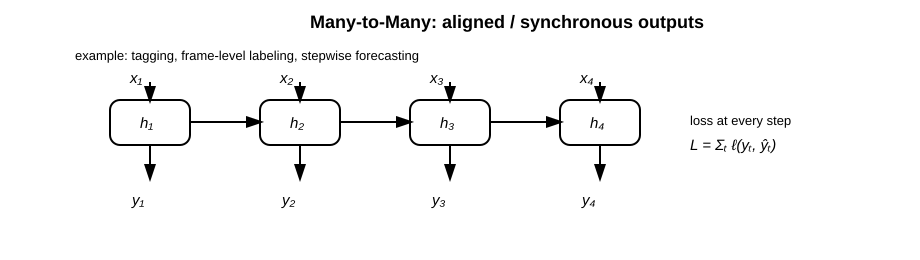

In [4]:
from IPython.display import SVG, display

many_to_many_aligned_svg = r'''<svg width="920" height="260" xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black"/>
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 10; ry: 10; }
    .smallbox { fill: white; stroke: black; stroke-width: 1.8; rx: 8; ry: 8; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow); }
    .dash { stroke: black; stroke-width: 2; stroke-dasharray: 6 6; fill: none; marker-end: url(#arrow); }
    .txt { font-family: Arial, sans-serif; font-size: 16px; }
    .small { font-family: Arial, sans-serif; font-size: 13px; }
    .math { font-family: Arial, sans-serif; font-size: 15px; font-style: italic; }
    .title { font-family: Arial, sans-serif; font-size: 18px; font-weight: bold; }
  </style>

  <text x="310" y="28" class="title">Many-to-Many: aligned / synchronous outputs</text>
  <text x="75" y="60" class="small">example: tagging, frame-level labeling, stepwise forecasting</text>
  <rect x="110" y="100" width="80" height="45" class="box"/><text x="140" y="128" class="math">h₁</text>
  <rect x="260" y="100" width="80" height="45" class="box"/><text x="290" y="128" class="math">h₂</text>
  <rect x="410" y="100" width="80" height="45" class="box"/><text x="440" y="128" class="math">h₃</text>
  <rect x="560" y="100" width="80" height="45" class="box"/><text x="590" y="128" class="math">h₄</text>
  <line x1="190" y1="122" x2="260" y2="122" class="line"/>
  <line x1="340" y1="122" x2="410" y2="122" class="line"/>
  <line x1="490" y1="122" x2="560" y2="122" class="line"/>
  <text x="130" y="83" class="math">x₁</text><line x1="150" y1="82" x2="150" y2="100" class="line"/>
  <text x="280" y="83" class="math">x₂</text><line x1="300" y1="82" x2="300" y2="100" class="line"/>
  <text x="430" y="83" class="math">x₃</text><line x1="450" y1="82" x2="450" y2="100" class="line"/>
  <text x="580" y="83" class="math">x₄</text><line x1="600" y1="82" x2="600" y2="100" class="line"/>
  <line x1="150" y1="145" x2="150" y2="178" class="line"/><text x="132" y="205" class="math">y₁</text>
  <line x1="300" y1="145" x2="300" y2="178" class="line"/><text x="282" y="205" class="math">y₂</text>
  <line x1="450" y1="145" x2="450" y2="178" class="line"/><text x="432" y="205" class="math">y₃</text>
  <line x1="600" y1="145" x2="600" y2="178" class="line"/><text x="582" y="205" class="math">y₄</text>
  <text x="690" y="125" class="small">loss at every step</text>
  <text x="690" y="150" class="math">L = Σₜ ℓ(yₜ, ŷₜ)</text>
</svg>'''
display(SVG(many_to_many_aligned_svg))


### 4.2 Many-to-one prediction

In many-to-one prediction, the input is a sequence but the target is a single label or value.

Typical examples:

- sentiment classification,
- document classification,
- activity recognition from sensor streams,
- fraud detection over a transaction window,
- predicting whether a patient sequence indicates risk.

A common choice is to use the final hidden state:

$$
y = g(W_y h_T + b_y),
$$

with loss:

$$
\mathcal{L} = \ell(y, \hat{y}).
$$

Even though the loss is attached only to $h_T$, the final state depends on the entire sequence:

$$
h_T
=
F_\theta(
F_\theta(
\cdots
F_\theta(h_0, x_1),
x_2),
\ldots,
x_T).
$$

Therefore, learning from early inputs still requires gradients to flow backward through many recurrent transitions.


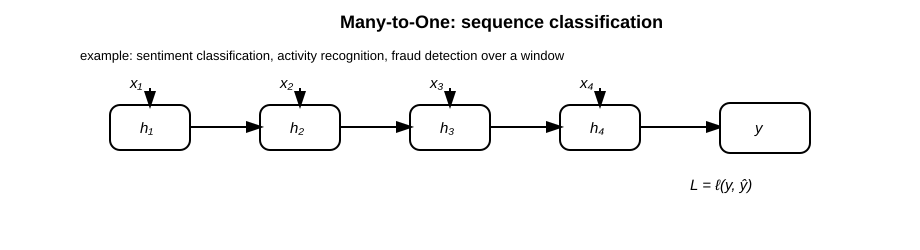

In [5]:
from IPython.display import SVG, display

many_to_one_svg = r'''<svg width="920" height="250" xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black"/>
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 10; ry: 10; }
    .smallbox { fill: white; stroke: black; stroke-width: 1.8; rx: 8; ry: 8; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow); }
    .dash { stroke: black; stroke-width: 2; stroke-dasharray: 6 6; fill: none; marker-end: url(#arrow); }
    .txt { font-family: Arial, sans-serif; font-size: 16px; }
    .small { font-family: Arial, sans-serif; font-size: 13px; }
    .math { font-family: Arial, sans-serif; font-size: 15px; font-style: italic; }
    .title { font-family: Arial, sans-serif; font-size: 18px; font-weight: bold; }
  </style>

  <text x="340" y="28" class="title">Many-to-One: sequence classification</text>
  <text x="80" y="60" class="small">example: sentiment classification, activity recognition, fraud detection over a window</text>
  <rect x="110" y="105" width="80" height="45" class="box"/><text x="140" y="133" class="math">h₁</text>
  <rect x="260" y="105" width="80" height="45" class="box"/><text x="290" y="133" class="math">h₂</text>
  <rect x="410" y="105" width="80" height="45" class="box"/><text x="440" y="133" class="math">h₃</text>
  <rect x="560" y="105" width="80" height="45" class="box"/><text x="590" y="133" class="math">h₄</text>
  <line x1="190" y1="127" x2="260" y2="127" class="line"/>
  <line x1="340" y1="127" x2="410" y2="127" class="line"/>
  <line x1="490" y1="127" x2="560" y2="127" class="line"/>
  <text x="130" y="88" class="math">x₁</text><line x1="150" y1="88" x2="150" y2="105" class="line"/>
  <text x="280" y="88" class="math">x₂</text><line x1="300" y1="88" x2="300" y2="105" class="line"/>
  <text x="430" y="88" class="math">x₃</text><line x1="450" y1="88" x2="450" y2="105" class="line"/>
  <text x="580" y="88" class="math">x₄</text><line x1="600" y1="88" x2="600" y2="105" class="line"/>
  <line x1="640" y1="127" x2="720" y2="127" class="line"/>
  <rect x="720" y="103" width="90" height="50" class="box"/><text x="755" y="133" class="math">y</text>
  <text x="690" y="190" class="math">L = ℓ(y, ŷ)</text>
</svg>'''
display(SVG(many_to_one_svg))


### 4.3 One-to-many prediction

In one-to-many prediction, a single conditioning input is used to generate a sequence.

Typical examples:

- image captioning, where an image embedding initializes a text generator,
- music generation from a seed vector,
- conditional sequence generation,
- generating a sequence from a fixed context representation.

One common formulation is to initialize the hidden state from the input:

$$
h_0 = f_\theta(x),
$$

then generate outputs recurrently:

$$
h_t = F_\theta(h_{t-1}, u_t),
$$

$$
y_t = g(W_y h_t + b_y),
$$

where $u_t$ may be the previous target token during teacher forcing or the previous model output during inference.

The sequence loss is:

$$
\mathcal{L}
=
\sum_{t=1}^{T_y}
\ell_t(y_t, \hat{y}_t).
$$

During training, it is common to use **teacher forcing**:

$$
u_t = \hat{y}_{t-1},
$$

while during inference the model must feed back its own prediction:

$$
u_t = y_{t-1}.
$$

This mismatch is one reason autoregressive generation can accumulate errors.


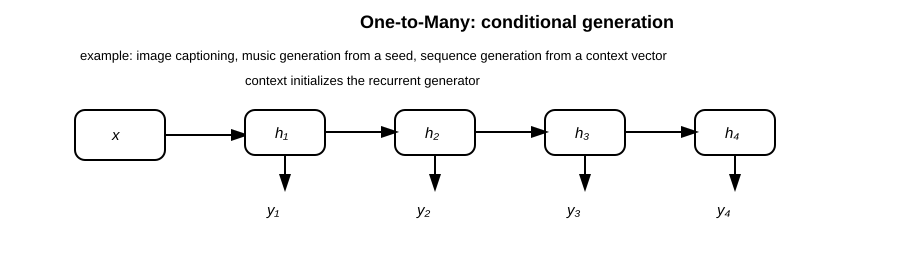

In [6]:
from IPython.display import SVG, display

one_to_many_svg = r'''<svg width="920" height="260" xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black"/>
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 10; ry: 10; }
    .smallbox { fill: white; stroke: black; stroke-width: 1.8; rx: 8; ry: 8; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow); }
    .dash { stroke: black; stroke-width: 2; stroke-dasharray: 6 6; fill: none; marker-end: url(#arrow); }
    .txt { font-family: Arial, sans-serif; font-size: 16px; }
    .small { font-family: Arial, sans-serif; font-size: 13px; }
    .math { font-family: Arial, sans-serif; font-size: 15px; font-style: italic; }
    .title { font-family: Arial, sans-serif; font-size: 18px; font-weight: bold; }
  </style>

  <text x="360" y="28" class="title">One-to-Many: conditional generation</text>
  <text x="80" y="60" class="small">example: image captioning, music generation from a seed, sequence generation from a context vector</text>
  <rect x="75" y="110" width="90" height="50" class="box"/><text x="112" y="140" class="math">x</text>
  <line x1="165" y1="135" x2="245" y2="135" class="line"/>
  <rect x="245" y="110" width="80" height="45" class="box"/><text x="275" y="138" class="math">h₁</text>
  <rect x="395" y="110" width="80" height="45" class="box"/><text x="425" y="138" class="math">h₂</text>
  <rect x="545" y="110" width="80" height="45" class="box"/><text x="575" y="138" class="math">h₃</text>
  <rect x="695" y="110" width="80" height="45" class="box"/><text x="725" y="138" class="math">h₄</text>
  <line x1="325" y1="132" x2="395" y2="132" class="line"/>
  <line x1="475" y1="132" x2="545" y2="132" class="line"/>
  <line x1="625" y1="132" x2="695" y2="132" class="line"/>
  <line x1="285" y1="155" x2="285" y2="188" class="line"/><text x="267" y="215" class="math">y₁</text>
  <line x1="435" y1="155" x2="435" y2="188" class="line"/><text x="417" y="215" class="math">y₂</text>
  <line x1="585" y1="155" x2="585" y2="188" class="line"/><text x="567" y="215" class="math">y₃</text>
  <line x1="735" y1="155" x2="735" y2="188" class="line"/><text x="717" y="215" class="math">y₄</text>
  <text x="245" y="85" class="small">context initializes the recurrent generator</text>
</svg>'''
display(SVG(one_to_many_svg))


### 4.4 Many-to-many, unaligned sequence-to-sequence

In unaligned many-to-many problems, the input and output lengths may differ:

$$
T_x \neq T_y.
$$

Typical examples:

- machine translation,
- abstractive summarization,
- speech recognition,
- question answering with generated text.

A classical recurrent encoder–decoder model has two parts.

The encoder reads the input:

$$
h_t^{\text{enc}}
=
F_{\theta_e}(h_{t-1}^{\text{enc}}, x_t),
\qquad t = 1, \ldots, T_x.
$$

The decoder generates the output:

$$
s_t
=
F_{\theta_d}(s_{t-1}, u_t, c),
\qquad t = 1, \ldots, T_y,
$$

where $c$ is a context vector, often chosen as the final encoder state:

$$
c = h_{T_x}^{\text{enc}}.
$$

The output distribution is:

$$
y_t = g(W_y s_t + b_y),
$$

and the loss is accumulated over decoder steps:

$$
\mathcal{L}
=
\sum_{t=1}^{T_y}
\ell_t(y_t, \hat{y}_t).
$$

The weakness of the basic encoder–decoder architecture is that the entire source sequence must be compressed into one vector $c$.
This creates an information bottleneck, especially for long sequences.


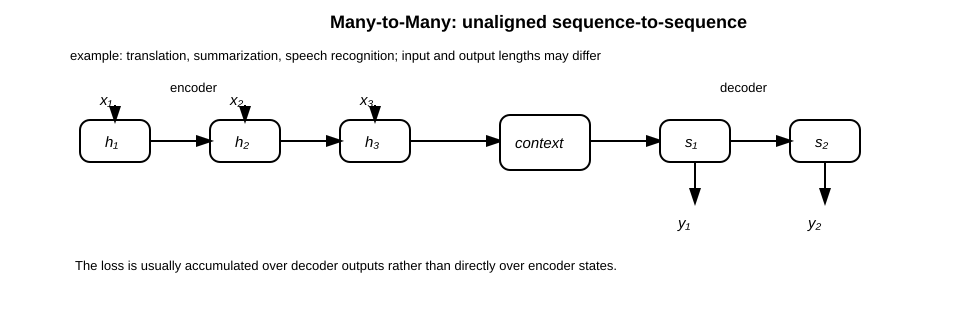

In [7]:
from IPython.display import SVG, display

seq2seq_unaligned_svg = r'''<svg width="960" height="310" xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black"/>
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 10; ry: 10; }
    .smallbox { fill: white; stroke: black; stroke-width: 1.8; rx: 8; ry: 8; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow); }
    .dash { stroke: black; stroke-width: 2; stroke-dasharray: 6 6; fill: none; marker-end: url(#arrow); }
    .txt { font-family: Arial, sans-serif; font-size: 16px; }
    .small { font-family: Arial, sans-serif; font-size: 13px; }
    .math { font-family: Arial, sans-serif; font-size: 15px; font-style: italic; }
    .title { font-family: Arial, sans-serif; font-size: 18px; font-weight: bold; }
  </style>

  <text x="330" y="28" class="title">Many-to-Many: unaligned sequence-to-sequence</text>
  <text x="70" y="60" class="small">example: translation, summarization, speech recognition; input and output lengths may differ</text>
  <text x="170" y="92" class="small">encoder</text>
  <rect x="80" y="120" width="70" height="42" class="box"/><text x="105" y="147" class="math">h₁</text>
  <rect x="210" y="120" width="70" height="42" class="box"/><text x="235" y="147" class="math">h₂</text>
  <rect x="340" y="120" width="70" height="42" class="box"/><text x="365" y="147" class="math">h₃</text>
  <line x1="150" y1="141" x2="210" y2="141" class="line"/>
  <line x1="280" y1="141" x2="340" y2="141" class="line"/>
  <text x="100" y="105" class="math">x₁</text><line x1="115" y1="105" x2="115" y2="120" class="line"/>
  <text x="230" y="105" class="math">x₂</text><line x1="245" y1="105" x2="245" y2="120" class="line"/>
  <text x="360" y="105" class="math">x₃</text><line x1="375" y1="105" x2="375" y2="120" class="line"/>
  <line x1="410" y1="141" x2="500" y2="141" class="line"/>
  <rect x="500" y="115" width="90" height="55" class="box"/><text x="515" y="148" class="math">context</text>
  <line x1="590" y1="141" x2="660" y2="141" class="line"/>
  <text x="720" y="92" class="small">decoder</text>
  <rect x="660" y="120" width="70" height="42" class="box"/><text x="685" y="147" class="math">s₁</text>
  <rect x="790" y="120" width="70" height="42" class="box"/><text x="815" y="147" class="math">s₂</text>
  <line x1="730" y1="141" x2="790" y2="141" class="line"/>
  <line x1="695" y1="162" x2="695" y2="202" class="line"/><text x="678" y="228" class="math">y₁</text>
  <line x1="825" y1="162" x2="825" y2="202" class="line"/><text x="808" y="228" class="math">y₂</text>
  <text x="75" y="270" class="small">The loss is usually accumulated over decoder outputs rather than directly over encoder states.</text>
</svg>'''
display(SVG(seq2seq_unaligned_svg))


### 4.5 Many-to-many with delay: language modeling and next-step prediction

In language modeling, the target at time $t$ is often the next token:

$$
\hat{y}_t = x_{t+1}.
$$

The RNN reads tokens one by one and predicts the next token distribution:

$$
h_t = F_\theta(h_{t-1}, x_t),
$$

$$
y_t = \operatorname{softmax}(W_y h_t + b_y).
$$

The loss is:

$$
\mathcal{L}
=
\sum_{t=1}^{T-1}
\ell(y_t, x_{t+1}).
$$

For a vocabulary classification problem, this is usually cross-entropy:

$$
\ell(y_t, x_{t+1})
=
-\log p_\theta(x_{t+1} \mid x_{\le t}).
$$

Thus the total negative log-likelihood is:

$$
\mathcal{L}
=
-\sum_{t=1}^{T-1}
\log p_\theta(x_{t+1} \mid x_1, \ldots, x_t).
$$


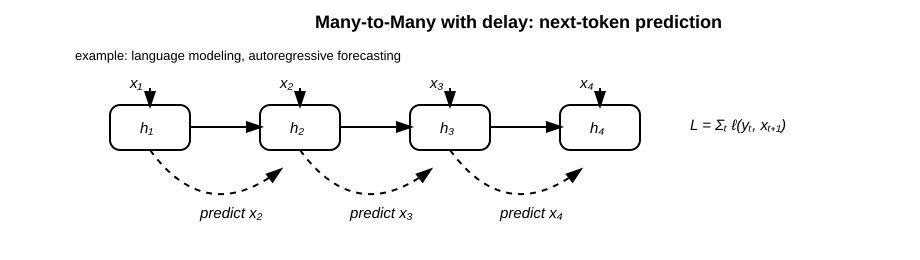

In [8]:
from IPython.display import SVG, display

delayed_many_to_many_svg = r'''<svg width="920" height="260" xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black"/>
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 10; ry: 10; }
    .smallbox { fill: white; stroke: black; stroke-width: 1.8; rx: 8; ry: 8; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow); }
    .dash { stroke: black; stroke-width: 2; stroke-dasharray: 6 6; fill: none; marker-end: url(#arrow); }
    .txt { font-family: Arial, sans-serif; font-size: 16px; }
    .small { font-family: Arial, sans-serif; font-size: 13px; }
    .math { font-family: Arial, sans-serif; font-size: 15px; font-style: italic; }
    .title { font-family: Arial, sans-serif; font-size: 18px; font-weight: bold; }
  </style>

  <text x="315" y="28" class="title">Many-to-Many with delay: next-token prediction</text>
  <text x="75" y="60" class="small">example: language modeling, autoregressive forecasting</text>
  <rect x="110" y="105" width="80" height="45" class="box"/><text x="140" y="133" class="math">h₁</text>
  <rect x="260" y="105" width="80" height="45" class="box"/><text x="290" y="133" class="math">h₂</text>
  <rect x="410" y="105" width="80" height="45" class="box"/><text x="440" y="133" class="math">h₃</text>
  <rect x="560" y="105" width="80" height="45" class="box"/><text x="590" y="133" class="math">h₄</text>
  <line x1="190" y1="127" x2="260" y2="127" class="line"/>
  <line x1="340" y1="127" x2="410" y2="127" class="line"/>
  <line x1="490" y1="127" x2="560" y2="127" class="line"/>
  <text x="130" y="88" class="math">x₁</text><line x1="150" y1="88" x2="150" y2="105" class="line"/>
  <text x="280" y="88" class="math">x₂</text><line x1="300" y1="88" x2="300" y2="105" class="line"/>
  <text x="430" y="88" class="math">x₃</text><line x1="450" y1="88" x2="450" y2="105" class="line"/>
  <text x="580" y="88" class="math">x₄</text><line x1="600" y1="88" x2="600" y2="105" class="line"/>
  <path d="M150 150 C190 205, 235 205, 280 170" class="dash"/><text x="200" y="218" class="math">predict x₂</text>
  <path d="M300 150 C340 205, 385 205, 430 170" class="dash"/><text x="350" y="218" class="math">predict x₃</text>
  <path d="M450 150 C490 205, 535 205, 580 170" class="dash"/><text x="500" y="218" class="math">predict x₄</text>
  <text x="690" y="130" class="math">L = Σₜ ℓ(yₜ, xₜ₊₁)</text>
</svg>'''
display(SVG(delayed_many_to_many_svg))


### 4.6 Encoder–decoder with attention: the bridge to modern attention

The bottleneck in the basic encoder–decoder model is the single context vector:

$$
c = h_{T_x}^{\text{enc}}.
$$

Attention replaces this single fixed vector with a decoder-dependent context vector:

$$
c_t
=
\sum_{i=1}^{T_x}
\alpha_{t,i} h_i^{\text{enc}},
$$

where the weights satisfy:

$$
\alpha_{t,i}
=
\frac{
\exp(e_{t,i})
}{
\sum_{j=1}^{T_x} \exp(e_{t,j})
}.
$$

The alignment score $e_{t,i}$ measures how relevant encoder state $h_i^{\text{enc}}$ is to decoder state $s_t$.
For example, additive attention uses:

$$
e_{t,i}
=
v^T \tanh(W_s s_t + W_h h_i^{\text{enc}}).
$$

This is the historical bridge from RNN encoder–decoder models to modern self-attention.
Instead of relying only on the latest recurrent state, the decoder can directly access all encoder states.


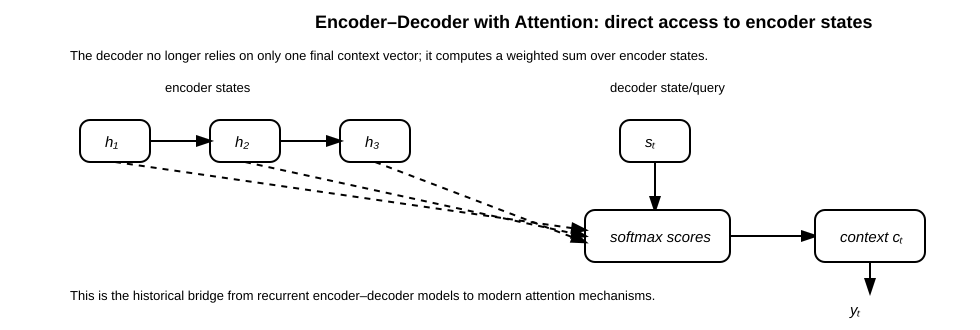

In [9]:
from IPython.display import SVG, display

encoder_decoder_attention_svg = r'''<svg width="980" height="330" xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black"/>
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 10; ry: 10; }
    .smallbox { fill: white; stroke: black; stroke-width: 1.8; rx: 8; ry: 8; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow); }
    .dash { stroke: black; stroke-width: 2; stroke-dasharray: 6 6; fill: none; marker-end: url(#arrow); }
    .txt { font-family: Arial, sans-serif; font-size: 16px; }
    .small { font-family: Arial, sans-serif; font-size: 13px; }
    .math { font-family: Arial, sans-serif; font-size: 15px; font-style: italic; }
    .title { font-family: Arial, sans-serif; font-size: 18px; font-weight: bold; }
  </style>

  <text x="315" y="28" class="title">Encoder–Decoder with Attention: direct access to encoder states</text>
  <text x="70" y="60" class="small">The decoder no longer relies on only one final context vector; it computes a weighted sum over encoder states.</text>
  <text x="165" y="92" class="small">encoder states</text>
  <rect x="80" y="120" width="70" height="42" class="box"/><text x="105" y="147" class="math">h₁</text>
  <rect x="210" y="120" width="70" height="42" class="box"/><text x="235" y="147" class="math">h₂</text>
  <rect x="340" y="120" width="70" height="42" class="box"/><text x="365" y="147" class="math">h₃</text>
  <line x1="150" y1="141" x2="210" y2="141" class="line"/>
  <line x1="280" y1="141" x2="340" y2="141" class="line"/>
  <rect x="620" y="120" width="70" height="42" class="box"/><text x="645" y="147" class="math">sₜ</text>
  <text x="610" y="92" class="small">decoder state/query</text>
  <line x1="655" y1="162" x2="655" y2="210" class="line"/>
  <rect x="585" y="210" width="145" height="52" class="box"/><text x="610" y="242" class="math">softmax scores</text>
  <line x1="115" y1="162" x2="585" y2="230" class="dash"/>
  <line x1="245" y1="162" x2="585" y2="236" class="dash"/>
  <line x1="375" y1="162" x2="585" y2="242" class="dash"/>
  <line x1="730" y1="236" x2="815" y2="236" class="line"/>
  <rect x="815" y="210" width="110" height="52" class="box"/><text x="840" y="242" class="math">context cₜ</text>
  <line x1="870" y1="262" x2="870" y2="292" class="line"/><text x="850" y="315" class="math">yₜ</text>
  <text x="70" y="300" class="small">This is the historical bridge from recurrent encoder–decoder models to modern attention mechanisms.</text>
</svg>'''
display(SVG(encoder_decoder_attention_svg))


### 4.7 Summary: the loss determines the supervision pattern

The same recurrent transition can support many sequence-learning problems. What changes is the placement of the loss.

| Mapping type | Input | Output | Typical loss placement | Examples |
|---|---:|---:|---|---|
| One-to-one | single item | single item | one output | ordinary classification/regression |
| Many-to-one | sequence | single item | final state or pooled states | sentiment, activity recognition |
| One-to-many | single item | sequence | every generated step | captioning, conditional generation |
| Many-to-many aligned | sequence | sequence, same alignment | every input step | tagging, frame labeling |
| Many-to-many delayed | sequence | shifted sequence | next-step targets | language modeling |
| Many-to-many unaligned | sequence | sequence, different length | decoder steps | translation, summarization |

The important mathematical point is this:

$$
\text{where the loss is attached determines how far gradients must travel.}
$$

If the loss at a later time depends on information from much earlier inputs, then the gradient must pass through repeated recurrent transitions. This is the central reason that vanishing and exploding gradients arise in RNNs.


# Part I — Backpropagation Through Time


## 5. Local Jacobian of the RNN transition

Consider the vanilla RNN:

$$
a_t = W_h h_{t-1} + W_x x_t + b_h,
$$

$$
h_t = \phi(a_t).
$$

Let

$$
D_t = \operatorname{diag}(\phi'(a_t)).
$$

Then the Jacobian of $h_t$ with respect to $h_{t-1}$ is

$$
J_t = \frac{\partial h_t}{\partial h_{t-1}}
= D_t W_h.
$$

This single matrix $J_t$ describes how a small perturbation in $h_{t-1}$ affects $h_t$.

The entire gradient-flow problem in vanilla RNNs is governed by products of these matrices.


## 6. BPTT derivation

For $k < t$, repeated application of the chain rule gives

$$
\frac{\partial h_t}{\partial h_k}
=
\frac{\partial h_t}{\partial h_{t-1}}
\frac{\partial h_{t-1}}{\partial h_{t-2}}
\cdots
\frac{\partial h_{k+1}}{\partial h_k}.
$$

Using $J_i = D_i W_h$,

$$
\frac{\partial h_t}{\partial h_k}
=
\prod_{i=k+1}^{t} J_i
=
\prod_{i=k+1}^{t} D_i W_h.
$$

If the loss depends on all hidden states,

$$
\mathcal{L} = \sum_{t=1}^{T} \ell_t(h_t),
$$

then the gradient with respect to an earlier hidden state $h_k$ is

$$
\frac{\partial \mathcal{L}}{\partial h_k}
=
\sum_{t=k}^{T}
\frac{\partial \ell_t}{\partial h_t}
\frac{\partial h_t}{\partial h_k}.
$$

Hence every long-range contribution contains a Jacobian product:

$$
G_{k \to t} = \prod_{i=k+1}^{t} D_i W_h.
$$

This product can shrink exponentially, grow exponentially, or remain approximately stable depending on the recurrent dynamics.


## 7. Parameter-gradient formulas

Let

$$
\delta_t = \frac{\partial \mathcal{L}}{\partial a_t}.
$$

For the vanilla RNN, the parameter gradients at time $t$ are

$$
\frac{\partial \mathcal{L}}{\partial W_h}
= \sum_{t=1}^{T} \delta_t h_{t-1}^{\top},
$$

$$
\frac{\partial \mathcal{L}}{\partial W_x}
= \sum_{t=1}^{T} \delta_t x_t^{\top},
$$

$$
\frac{\partial \mathcal{L}}{\partial b_h}
= \sum_{t=1}^{T} \delta_t.
$$

The backward recurrence for hidden-state gradients is

$$
\frac{\partial \mathcal{L}}{\partial h_{t-1}}
=
\frac{\partial \mathcal{L}}{\partial h_t} J_t
=
\frac{\partial \mathcal{L}}{\partial h_t} D_t W_h.
$$

Depending on row-vector or column-vector convention, the transpose may appear. The essential point is unchanged: gradients are repeatedly multiplied by recurrent Jacobians.


# Part II — Vanishing and Exploding Gradients


## 8. Norm-based proof of exponential decay or growth

Let $\|\cdot\|$ be any submultiplicative matrix norm, meaning

$$
\|AB\| \le \|A\|\|B\|.
$$

Then

$$
\left\|
\frac{\partial h_t}{\partial h_k}
\right\|
=
\left\|
\prod_{i=k+1}^{t} D_i W_h
\right\|
\le
\prod_{i=k+1}^{t} \|D_i\|\,\|W_h\|.
$$

Suppose there exists $\gamma < 1$ such that

$$
\|D_i\|\,\|W_h\| \le \gamma
\qquad \text{for all } i.
$$

Then

$$
\left\|
\frac{\partial h_t}{\partial h_k}
\right\|
\le
\gamma^{t-k}.
$$

Since $\gamma^{t-k}$ decays exponentially with distance $t-k$, long-range gradients vanish.

Conversely, if the typical gain satisfies

$$
\|D_i\|\,\|W_h\| > 1,
$$

then Jacobian products may grow exponentially, producing exploding gradients.

This is not a minor optimization issue. It is a structural consequence of repeatedly composing the same transition function over time.


## 9. Spectral-radius view

The norm proof gives an upper bound. The spectral-radius view gives geometric intuition.

For a linear RNN without nonlinearity,

$$
h_t = W_h h_{t-1}.
$$

Then

$$
h_t = W_h^t h_0.
$$

If $W_h$ is diagonalizable,

$$
W_h = P \Lambda P^{-1},
$$

so

$$
W_h^t = P \Lambda^t P^{-1}.
$$

The eigenvalues of $W_h$ are raised to the $t$-th power:

$$
\Lambda^t = \operatorname{diag}(\lambda_1^t, \ldots, \lambda_{d_h}^t).
$$

The spectral radius is

$$
\rho(W_h) = \max_i |\lambda_i|.
$$

Therefore:

- if $\rho(W_h) < 1$, recurrent signals tend to contract;
- if $\rho(W_h) > 1$, recurrent signals may expand;
- if $\rho(W_h) \approx 1$, signals may be more stable.

For nonlinear RNNs, the relevant object is not just $W_h$, but the local Jacobian

$$
J_t = D_t W_h.
$$

The long-range gradient depends on

$$
J_t J_{t-1} \cdots J_{k+1}.
$$

Thus the effective stability depends on both recurrent weights and activation derivatives.


## 10. Gradient-flow diagram

A gradient signal traveling through time is repeatedly transformed. The repeated product behaves like an exponential process:

$$
\left\| \frac{\partial h_t}{\partial h_k} \right\| \lesssim \gamma^{t-k}.
$$

If $\gamma < 1$, the signal decays exponentially; if $\gamma > 1$, it grows exponentially.


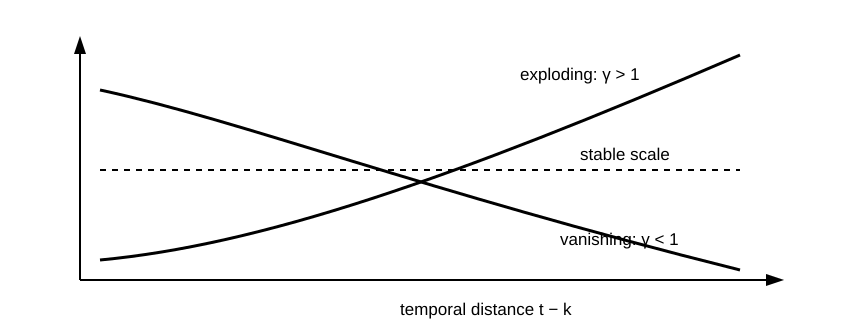

In [2]:
from IPython.display import SVG, display

gradient_flow_svg = r'''<svg width="850" height="330" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arr_grad" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black" />
    </marker>
  </defs>
  <style>
    .axis { stroke: black; stroke-width: 2; }
    .line { stroke: black; stroke-width: 3; fill: none; }
    .dash { stroke: black; stroke-width: 2; stroke-dasharray: 6 6; }
    .txt { font-family: Arial; font-size: 17px; }
  </style>
  <line x1="80" y1="280" x2="780" y2="280" class="axis" marker-end="url(#arr_grad)" />
  <line x1="80" y1="280" x2="80" y2="40" class="axis" marker-end="url(#arr_grad)" />
  <text x="400" y="315" class="txt">temporal distance t − k</text>
  <text x="15" y="55" class="txt" transform="rotate(-90 20,80)">gradient norm</text>

  <path d="M100 90 C240 120, 420 190, 740 270" class="line" />
  <text x="560" y="245" class="txt">vanishing: γ &lt; 1</text>

  <path d="M100 260 C260 245, 450 180, 740 55" class="line" />
  <text x="520" y="80" class="txt">exploding: γ &gt; 1</text>

  <line x1="100" y1="170" x2="740" y2="170" class="dash" />
  <text x="580" y="160" class="txt">stable scale</text>
</svg>'''
display(SVG(gradient_flow_svg))


## 11. Why tanh and sigmoid saturate

For $\tanh$,

$$
\frac{d}{dz}\tanh(z) = 1 - \tanh^2(z).
$$

This derivative is close to $1$ only near $z=0$, and approaches $0$ as $|z|$ grows.

For sigmoid,

$$
\sigma(z) = \frac{1}{1 + e^{-z}},
$$

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z)).
$$

The maximum derivative is

$$
\max_z \sigma'(z) = \frac{1}{4}.
$$

Therefore, sigmoid gates naturally shrink gradients unless they are used carefully. LSTM and GRU use sigmoids for gates, but they also introduce additive state paths that avoid repeatedly applying a saturating nonlinearity to the memory itself.


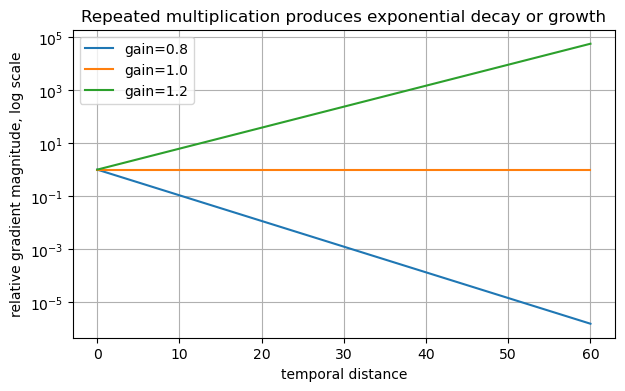

In [3]:
# Numerical experiment: vanishing and exploding gradients in a simple recurrent product
# This cell is educational. It does not train a model; it visualizes powers of a scalar gain.

import numpy as np
import matplotlib.pyplot as plt

T = 60
dist = np.arange(T + 1)

gains = [0.8, 1.0, 1.2]

plt.figure(figsize=(7, 4))
for g in gains:
    plt.plot(dist, g ** dist, label=f"gain={g}")
plt.yscale("log")
plt.xlabel("temporal distance")
plt.ylabel("relative gradient magnitude, log scale")
plt.title("Repeated multiplication produces exponential decay or growth")
plt.legend()
plt.grid(True)
plt.show()


## 12. Practical remedies

### 12.1 Gradient clipping

If the gradient norm exceeds a threshold $c$, rescale it:

$$
g \leftarrow c \frac{g}{\|g\|}
\qquad \text{if } \|g\| > c.
$$

Gradient clipping does not solve vanishing gradients, but it is highly effective against exploding gradients.

### 12.2 Orthogonal initialization

If $W_h$ is orthogonal,

$$
W_h^\top W_h = I,
$$

then

$$
\|W_h v\|_2 = \|v\|_2.
$$

This helps preserve gradient norms in the linear component of recurrence.

### 12.3 Truncated BPTT

Instead of backpropagating through all $T$ steps, truncate the computational graph after $K$ steps. This reduces memory and improves stability, but limits how far gradients can travel.

### 12.4 Gated recurrent units

LSTM and GRU introduce gates that regulate information flow. Their key advantage is not merely that they are more complex, but that they create more stable gradient paths.


# Part III — Implementing Vanilla RNNs


In [10]:
# Manual PyTorch implementation of a vanilla RNN cell
# Shapes assume batch_first=True: x has shape (batch, time, input_size)

import torch
import torch.nn as nn

class ManualRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_x = nn.Linear(input_size, hidden_size, bias=False)
        self.W_h = nn.Linear(hidden_size, hidden_size, bias=True)
        self.W_y = nn.Linear(hidden_size, output_size, bias=True)

    def forward(self, x, h0=None):
        batch_size, seq_len, _ = x.shape
        if h0 is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        else:
            h = h0

        hidden_states = []
        outputs = []

        for t in range(seq_len):
            # h_t = tanh(W_x x_t + W_h h_{t-1})
            h = torch.tanh(self.W_x(x[:, t, :]) + self.W_h(h))
            y = self.W_y(h)
            hidden_states.append(h.unsqueeze(1))
            outputs.append(y.unsqueeze(1))

        H = torch.cat(hidden_states, dim=1)
        Y = torch.cat(outputs, dim=1)
        return Y, H


## 13. Built-in PyTorch RNN layer

PyTorch provides `torch.nn.RNN`, which implements the same recurrence more efficiently.

For one layer and tanh nonlinearity, conceptually it computes

$$
h_t = \tanh(x_t W_{ih}^\top + b_{ih} + h_{t-1} W_{hh}^\top + b_{hh}).
$$

This corresponds to our notation as follows:

| Mathematical notation | PyTorch parameter name |
|---|---|
| $W_x$ | `weight_ih_l0` |
| $W_h$ | `weight_hh_l0` |
| input bias | `bias_ih_l0` |
| recurrent bias | `bias_hh_l0` |

Why start from manual code in a course?

- Manual recurrence exposes the mathematical structure.
- Built-in layers hide the Jacobian products that cause vanishing/exploding gradients.
- Once the theory is understood, the built-in API is preferred for practical engineering.


In [11]:
# Built-in PyTorch RNN

input_size = 8
hidden_size = 16
output_size = 4
batch_size = 3
seq_len = 5

x = torch.randn(batch_size, seq_len, input_size)

rnn = nn.RNN(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=1,
    nonlinearity="tanh",
    batch_first=True,
)

readout = nn.Linear(hidden_size, output_size)

H, h_n = rnn(x)      # H: all hidden states, h_n: final hidden state
Y = readout(H)       # output at every time step

print("H shape:", H.shape)
print("h_n shape:", h_n.shape)
print("Y shape:", Y.shape)


H shape: torch.Size([3, 5, 16])
h_n shape: torch.Size([1, 3, 16])
Y shape: torch.Size([3, 5, 4])


In [12]:
# Gradient clipping in a training loop

model = nn.RNN(input_size=8, hidden_size=16, batch_first=True)
head = nn.Linear(16, 4)
optimizer = torch.optim.Adam(list(model.parameters()) + list(head.parameters()), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

x = torch.randn(10, 20, 8)          # batch, time, features
target = torch.randint(0, 4, (10,)) # many-to-one classification target

optimizer.zero_grad()
H, h_n = model(x)
logits = head(h_n[-1])              # use final hidden state
loss = loss_fn(logits, target)
loss.backward()

torch.nn.utils.clip_grad_norm_(list(model.parameters()) + list(head.parameters()), max_norm=1.0)
optimizer.step()

print("loss:", float(loss.detach()))


loss: 1.4186551570892334


# Part IV — LSTM


## 14. Motivation for LSTM

A vanilla RNN updates memory by repeatedly applying

$$
h_t = \phi(W_h h_{t-1} + W_x x_t + b).
$$

This forces information to pass through a nonlinear transformation at every step. LSTM changes the design by introducing a separate cell state $c_t$ with an additive update:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t.
$$

This is the critical structural difference.

Instead of replacing memory completely, the LSTM can retain, erase, or add information through gates.


## 15. LSTM equations

Given input $x_t$, previous hidden state $h_{t-1}$, and previous cell state $c_{t-1}$:

### Forget gate

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f).
$$

This controls how much previous memory is retained.

### Input gate

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i).
$$

This controls how much new candidate information enters memory.

### Candidate memory

$$
\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c).
$$

### Cell-state update

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t.
$$

### Output gate

$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o).
$$

### Hidden-state update

$$
h_t = o_t \odot \tanh(c_t).
$$

The hidden state $h_t$ is exposed to the rest of the network, while $c_t$ acts as the internal memory highway.


## 16. LSTM cell diagram

The LSTM introduces a separate memory state $c_t$ and gates that control what is forgotten, written, and exposed:

$$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f),$$
$$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i),$$
$$\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c),$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t,$$
$$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o),$$
$$h_t = o_t \odot \tanh(c_t).$$


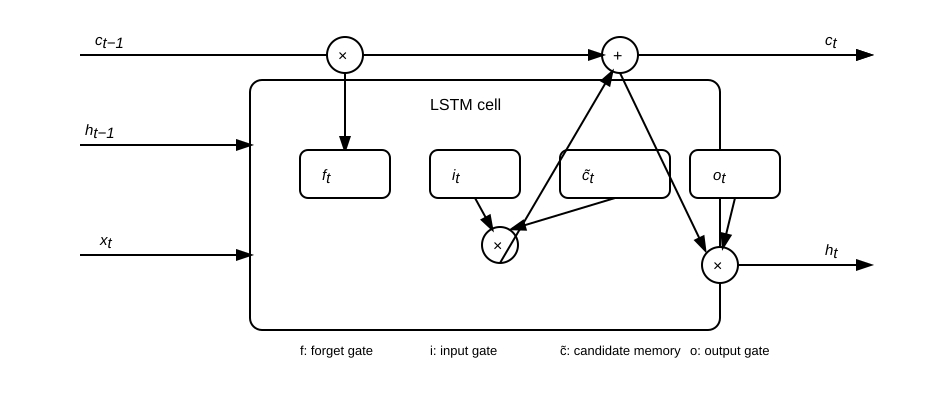

In [13]:
from IPython.display import SVG, display

lstm_cell_svg = r'''<svg width="950" height="420" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arrow_lstm" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black" />
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 12; ry: 12; }
    .gate { fill: white; stroke: black; stroke-width: 2; rx: 8; ry: 8; }
    .op { fill: white; stroke: black; stroke-width: 2; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow_lstm); }
    .txt { font-family: Arial; font-size: 16px; }
    .small { font-family: Arial; font-size: 13px; }
    .math { font-family: Arial; font-size: 15px; font-style: italic; }
  </style>

  <rect x="250" y="80" width="470" height="250" class="box" />
  <text x="430" y="110" class="txt">LSTM cell</text>

  <line x1="80" y1="145" x2="250" y2="145" class="line" />
  <text x="85" y="135" class="math">h<tspan baseline-shift="sub">t−1</tspan></text>

  <line x1="80" y1="255" x2="250" y2="255" class="line" />
  <text x="100" y="245" class="math">x<tspan baseline-shift="sub">t</tspan></text>

  <line x1="80" y1="55" x2="870" y2="55" class="line" />
  <text x="95" y="45" class="math">c<tspan baseline-shift="sub">t−1</tspan></text>

  <circle cx="345" cy="55" r="18" class="op"/>
  <text x="338" y="61" class="txt">×</text>
  <line x1="345" y1="73" x2="345" y2="150" class="line"/>

  <rect x="300" y="150" width="90" height="48" class="gate" />
  <text x="322" y="180" class="math">f<tspan baseline-shift="sub">t</tspan></text>

  <rect x="430" y="150" width="90" height="48" class="gate" />
  <text x="452" y="180" class="math">i<tspan baseline-shift="sub">t</tspan></text>

  <rect x="560" y="150" width="110" height="48" class="gate" />
  <text x="582" y="180" class="math">c̃<tspan baseline-shift="sub">t</tspan></text>

  <circle cx="500" cy="245" r="18" class="op"/>
  <text x="493" y="251" class="txt">×</text>
  <line x1="475" y1="198" x2="492" y2="229" class="line"/>
  <line x1="615" y1="198" x2="512" y2="229" class="line"/>

  <circle cx="620" cy="55" r="18" class="op"/>
  <text x="613" y="61" class="txt">+</text>
  <line x1="363" y1="55" x2="602" y2="55" class="line"/>
  <line x1="500" y1="263" x2="612" y2="72" class="line"/>

  <line x1="638" y1="55" x2="870" y2="55" class="line"/>
  <text x="825" y="45" class="math">c<tspan baseline-shift="sub">t</tspan></text>

  <rect x="690" y="150" width="90" height="48" class="gate" />
  <text x="713" y="180" class="math">o<tspan baseline-shift="sub">t</tspan></text>

  <line x1="620" y1="73" x2="705" y2="250" class="line"/>
  <circle cx="720" cy="265" r="18" class="op"/>
  <text x="713" y="271" class="txt">×</text>
  <line x1="735" y1="198" x2="723" y2="247" class="line"/>

  <line x1="738" y1="265" x2="870" y2="265" class="line"/>
  <text x="825" y="255" class="math">h<tspan baseline-shift="sub">t</tspan></text>

  <text x="300" y="355" class="small">f: forget gate</text>
  <text x="430" y="355" class="small">i: input gate</text>
  <text x="560" y="355" class="small">c̃: candidate memory</text>
  <text x="690" y="355" class="small">o: output gate</text>
</svg>'''
display(SVG(lstm_cell_svg))


## 17. Why LSTM helps gradients: the key proof

The LSTM cell update is

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t.
$$

Ignoring indirect dependencies of the gates on $c_{t-1}$ for the moment, the direct derivative is

$$
\frac{\partial c_t}{\partial c_{t-1}} = \operatorname{diag}(f_t).
$$

For multiple steps,

$$
\frac{\partial c_t}{\partial c_k}
\approx
\prod_{i=k+1}^{t} \operatorname{diag}(f_i).
$$

If the forget gates learn values near one,

$$
f_i \approx 1,
$$

then

$$
\frac{\partial c_t}{\partial c_k} \approx I.
$$

This gives the model an approximate identity path for gradients.

### Interpretation

Vanilla RNN memory is repeatedly overwritten:

$$
h_t = \phi(\text{new affine transformation}).
$$

LSTM memory is selectively accumulated:

$$
c_t = \text{retained old memory} + \text{controlled new memory}.
$$

The additive structure is the essential mathematical reason LSTMs can learn longer dependencies.


In [8]:
# Manual PyTorch implementation of an LSTM cell

class ManualLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.x_proj = nn.Linear(input_size, 4 * hidden_size)
        self.h_proj = nn.Linear(hidden_size, 4 * hidden_size, bias=False)

    def forward(self, x_t, state):
        h_prev, c_prev = state
        gates = self.x_proj(x_t) + self.h_proj(h_prev)
        f, i, g, o = gates.chunk(4, dim=-1)

        f = torch.sigmoid(f)       # forget gate
        i = torch.sigmoid(i)       # input gate
        g = torch.tanh(g)          # candidate memory
        o = torch.sigmoid(o)       # output gate

        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c

class ManualLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.cell = ManualLSTMCell(input_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []
        for t in range(seq_len):
            h, c = self.cell(x[:, t], (h, c))
            outputs.append(h.unsqueeze(1))
        return torch.cat(outputs, dim=1), (h, c)


In [9]:
# Built-in PyTorch LSTM

lstm = nn.LSTM(input_size=8, hidden_size=16, num_layers=1, batch_first=True)
x = torch.randn(4, 10, 8)

H, (h_n, c_n) = lstm(x)

print("All hidden states:", H.shape)
print("Final hidden state:", h_n.shape)
print("Final cell state:", c_n.shape)


All hidden states: torch.Size([4, 10, 16])
Final hidden state: torch.Size([1, 4, 16])
Final cell state: torch.Size([1, 4, 16])


# Part V — GRU


## 18. GRU motivation

The Gated Recurrent Unit (GRU) is a simpler gated architecture than LSTM. It has no separate cell state. Instead, it directly updates the hidden state using gates.

The GRU uses:

- reset gate $r_t$,
- update gate $z_t$,
- candidate hidden state $\tilde{h}_t$.

The update gate plays a role similar to interpolation between old memory and new memory.


## 19. GRU equations

### Update gate

$$
z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z).
$$

### Reset gate

$$
r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r).
$$

### Candidate hidden state

$$
\tilde{h}_t = \tanh(W_h x_t + U_h(r_t \odot h_{t-1}) + b_h).
$$

### Hidden-state update

A common convention is

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t.
$$

If $z_t$ is small, the model keeps the old state. If $z_t$ is large, the model writes new information.

This additive interpolation again creates a more stable gradient route than a vanilla RNN.


## 20. GRU diagram

The GRU merges the hidden state and memory state. It uses an update gate $z_t$ and reset gate $r_t$:

$$z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z),$$
$$r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r),$$
$$\tilde{h}_t = \tanh(W_h x_t + U_h(r_t \odot h_{t-1}) + b_h),$$
$$h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t.$$


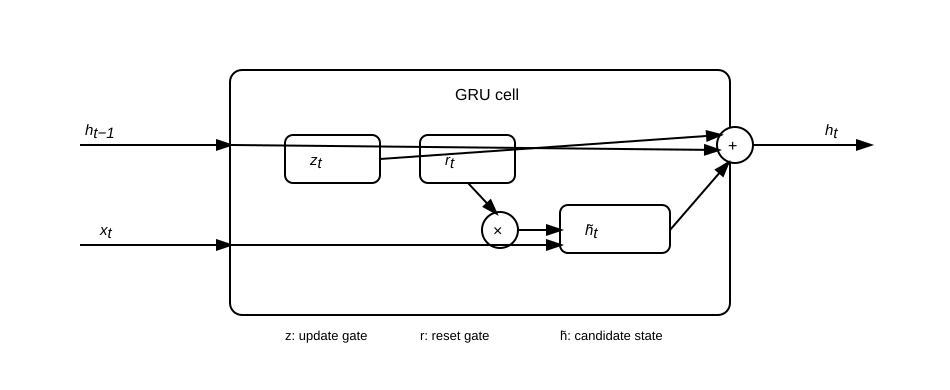

In [10]:
from IPython.display import SVG, display

gru_cell_svg = r'''<svg width="950" height="390" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arrow_gru" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black" />
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 12; ry: 12; }
    .gate { fill: white; stroke: black; stroke-width: 2; rx: 8; ry: 8; }
    .op { fill: white; stroke: black; stroke-width: 2; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow_gru); }
    .txt { font-family: Arial; font-size: 16px; }
    .small { font-family: Arial; font-size: 13px; }
    .math { font-family: Arial; font-size: 15px; font-style: italic; }
  </style>

  <rect x="230" y="70" width="500" height="245" class="box" />
  <text x="455" y="100" class="txt">GRU cell</text>

  <line x1="80" y1="145" x2="230" y2="145" class="line" />
  <text x="85" y="135" class="math">h<tspan baseline-shift="sub">t−1</tspan></text>

  <line x1="80" y1="245" x2="230" y2="245" class="line" />
  <text x="100" y="235" class="math">x<tspan baseline-shift="sub">t</tspan></text>

  <rect x="285" y="135" width="95" height="48" class="gate" />
  <text x="310" y="165" class="math">z<tspan baseline-shift="sub">t</tspan></text>

  <rect x="420" y="135" width="95" height="48" class="gate" />
  <text x="445" y="165" class="math">r<tspan baseline-shift="sub">t</tspan></text>

  <circle cx="500" cy="230" r="18" class="op"/>
  <text x="493" y="236" class="txt">×</text>
  <line x1="468" y1="183" x2="496" y2="213" class="line"/>

  <rect x="560" y="205" width="110" height="48" class="gate" />
  <text x="585" y="235" class="math">h̃<tspan baseline-shift="sub">t</tspan></text>

  <line x1="518" y1="230" x2="560" y2="230" class="line"/>
  <line x1="230" y1="245" x2="560" y2="245" class="line"/>

  <circle cx="735" cy="145" r="18" class="op"/>
  <text x="728" y="151" class="txt">+</text>

  <line x1="380" y1="159" x2="720" y2="135" class="line"/>
  <line x1="670" y1="230" x2="728" y2="163" class="line"/>
  <line x1="230" y1="145" x2="718" y2="150" class="line"/>

  <line x1="753" y1="145" x2="870" y2="145" class="line"/>
  <text x="825" y="135" class="math">h<tspan baseline-shift="sub">t</tspan></text>

  <text x="285" y="340" class="small">z: update gate</text>
  <text x="420" y="340" class="small">r: reset gate</text>
  <text x="560" y="340" class="small">h̃: candidate state</text>
</svg>'''
display(SVG(gru_cell_svg))


In [11]:
# Manual PyTorch implementation of a GRU cell

class ManualGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.x_z = nn.Linear(input_size, hidden_size)
        self.h_z = nn.Linear(hidden_size, hidden_size, bias=False)
        self.x_r = nn.Linear(input_size, hidden_size)
        self.h_r = nn.Linear(hidden_size, hidden_size, bias=False)
        self.x_h = nn.Linear(input_size, hidden_size)
        self.h_h = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev):
        z = torch.sigmoid(self.x_z(x_t) + self.h_z(h_prev))
        r = torch.sigmoid(self.x_r(x_t) + self.h_r(h_prev))
        h_tilde = torch.tanh(self.x_h(x_t) + self.h_h(r * h_prev))
        h = (1 - z) * h_prev + z * h_tilde
        return h

class ManualGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.cell = ManualGRUCell(input_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []
        for t in range(seq_len):
            h = self.cell(x[:, t], h)
            outputs.append(h.unsqueeze(1))
        return torch.cat(outputs, dim=1), h


In [12]:
# Built-in PyTorch GRU

gru = nn.GRU(input_size=8, hidden_size=16, num_layers=1, batch_first=True)
x = torch.randn(4, 10, 8)
H, h_n = gru(x)

print("All hidden states:", H.shape)
print("Final hidden state:", h_n.shape)


All hidden states: torch.Size([4, 10, 16])
Final hidden state: torch.Size([1, 4, 16])


# Part VI — JAX implementation sketch


In [13]:
# JAX-style vanilla RNN cell
# This cell is a compact implementation sketch. It requires jax to be installed.

# import jax
# import jax.numpy as jnp
# from jax import random
#
# def rnn_step(params, h_prev, x_t):
#     W_x, W_h, b = params["W_x"], params["W_h"], params["b"]
#     h = jnp.tanh(x_t @ W_x.T + h_prev @ W_h.T + b)
#     return h, h
#
# def rnn_forward(params, x, h0):
#     # x shape: (time, input_size)
#     h_final, H = jax.lax.scan(lambda h, x_t: rnn_step(params, h, x_t), h0, x)
#     return H, h_final
#
# # The key JAX idea is that recurrence is represented as a scan.
# # This mirrors the mathematical recursion while remaining compilable and differentiable.


# Part VII — Attention as the next step after RNNs


## 21. Why attention emerged

RNNs compress the past into one hidden vector:

$$
h_t = F(h_{t-1}, x_t).
$$

This creates a bottleneck. If information from $x_1$ is needed at time $T$, it must survive through many transitions:

$$
x_1 \to h_1 \to h_2 \to \cdots \to h_T.
$$

Attention changes the design. Instead of forcing all information through a single sequential state, it allows direct access to all representations:

$$
h_t \leftarrow \{h_1, h_2, \ldots, h_T\}.
$$

The conceptual shift is:

| RNN | Attention |
|---|---|
| sequential state propagation | direct memory access |
| fixed recurrent transition | data-dependent interactions |
| path length grows with distance | path length can be one |
| hard long-range gradients | direct pairwise connections |


## 22. From $W_x, W_h, W_y$ to $W_Q, W_K, W_V$

In a vanilla RNN, the key matrices are:

- $W_x$: transforms current input into hidden space,
- $W_h$: transforms previous hidden state into current hidden space,
- $W_y$: transforms hidden state into output space.

Attention uses a different decomposition. Given token representations collected in a matrix

$$
X \in \mathbb{R}^{T \times d},
$$

self-attention forms

$$
Q = XW_Q,
$$

$$
K = XW_K,
$$

$$
V = XW_V.
$$

These have different roles:

- Query $Q$: what the current position is looking for.
- Key $K$: what each position offers as an address.
- Value $V$: the information retrieved if a position is attended to.

The attention output is

$$
\operatorname{Attention}(Q,K,V)
=
\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

The matrix $QK^\top$ computes pairwise compatibility scores. The multiplication by $V$ retrieves and mixes information.

### Important clarification

$W_Q$, $W_K$, and $W_V$ are not a direct one-to-one replacement for $W_x$, $W_h$, and $W_y$. Instead, they solve a different problem:

- RNN weights define how memory is updated sequentially.
- Attention weights define how tokens read from each other directly.

So attention is not merely an RNN with different matrix names. It is a different memory-access mechanism.


## 23. Attention diagram

Attention replaces purely sequential state propagation with direct, content-dependent memory access:

$$Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V,$$
$$\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V.$$

The matrices $W_Q$, $W_K$, and $W_V$ are learned projections that separate three roles: querying, matching, and retrieving.


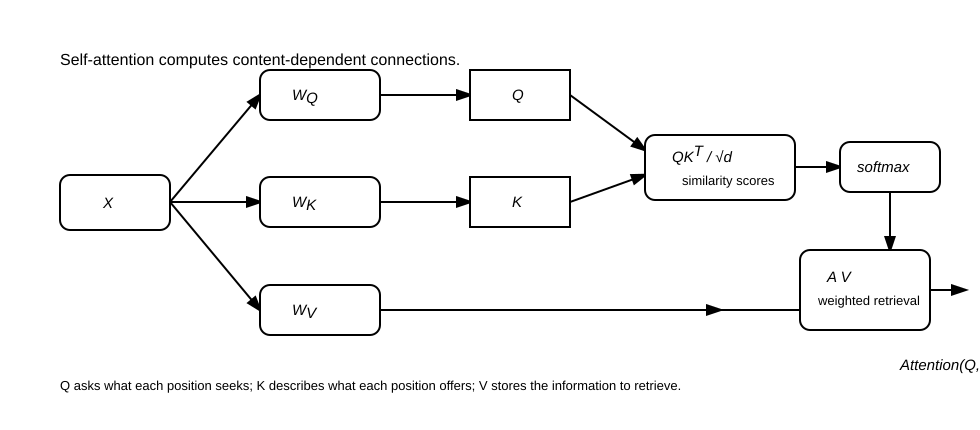

In [14]:
from IPython.display import SVG, display

attention_svg = r'''<svg width="980" height="430" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arrow_attn" markerWidth="10" markerHeight="10" refX="7" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="black" />
    </marker>
  </defs>
  <style>
    .box { fill: white; stroke: black; stroke-width: 2; rx: 10; ry: 10; }
    .mat { fill: white; stroke: black; stroke-width: 2; }
    .line { stroke: black; stroke-width: 2; fill: none; marker-end: url(#arrow_attn); }
    .txt { font-family: Arial; font-size: 16px; }
    .small { font-family: Arial; font-size: 13px; }
    .math { font-family: Arial; font-size: 15px; font-style: italic; }
  </style>

  <rect x="60" y="175" width="110" height="55" class="box"/>
  <text x="103" y="208" class="math">X</text>

  <line x1="170" y1="202" x2="260" y2="95" class="line"/>
  <line x1="170" y1="202" x2="260" y2="202" class="line"/>
  <line x1="170" y1="202" x2="260" y2="310" class="line"/>

  <rect x="260" y="70" width="120" height="50" class="box"/>
  <text x="292" y="100" class="math">W<tspan baseline-shift="sub">Q</tspan></text>

  <rect x="260" y="177" width="120" height="50" class="box"/>
  <text x="292" y="207" class="math">W<tspan baseline-shift="sub">K</tspan></text>

  <rect x="260" y="285" width="120" height="50" class="box"/>
  <text x="292" y="315" class="math">W<tspan baseline-shift="sub">V</tspan></text>

  <line x1="380" y1="95" x2="470" y2="95" class="line"/>
  <line x1="380" y1="202" x2="470" y2="202" class="line"/>
  <line x1="380" y1="310" x2="720" y2="310" class="line"/>

  <rect x="470" y="70" width="100" height="50" class="mat"/>
  <text x="512" y="100" class="math">Q</text>

  <rect x="470" y="177" width="100" height="50" class="mat"/>
  <text x="512" y="207" class="math">K</text>

  <line x1="570" y1="95" x2="645" y2="150" class="line"/>
  <line x1="570" y1="202" x2="645" y2="175" class="line"/>

  <rect x="645" y="135" width="150" height="65" class="box"/>
  <text x="672" y="162" class="math">QK<tspan baseline-shift="super">T</tspan> / √d</text>
  <text x="682" y="185" class="small">similarity scores</text>

  <line x1="795" y1="167" x2="840" y2="167" class="line"/>
  <rect x="840" y="142" width="100" height="50" class="box"/>
  <text x="857" y="172" class="math">softmax</text>

  <line x1="890" y1="192" x2="890" y2="250" class="line"/>
  <line x1="720" y1="310" x2="870" y2="310" class="line"/>

  <rect x="800" y="250" width="130" height="80" class="box"/>
  <text x="827" y="282" class="math">A V</text>
  <text x="818" y="305" class="small">weighted retrieval</text>

  <line x1="930" y1="290" x2="965" y2="290" class="line"/>
  <text x="900" y="370" class="math">Attention(Q,K,V)</text>

  <text x="60" y="65" class="txt">Self-attention computes content-dependent connections.</text>
  <text x="60" y="390" class="small">Q asks what each position seeks; K describes what each position offers; V stores the information to retrieve.</text>
</svg>'''
display(SVG(attention_svg))


## 24. Why attention helps with gradient flow

In an RNN, information from position $i$ reaches position $j$ through $j-i$ recurrent transitions:

$$
h_i \to h_{i+1} \to \cdots \to h_j.
$$

The gradient contains a product of many Jacobians:

$$
\prod_{t=i+1}^{j} J_t.
$$

In self-attention, position $j$ can directly attend to position $i$:

$$
z_j = \sum_{i=1}^{T} \alpha_{j,i} v_i.
$$

The path from $v_i$ to $z_j$ is direct. This does not mean transformers have no optimization difficulties, but it removes the recurrent temporal chain as the main route for information flow.

This is why attention became dominant for large-scale language modeling.


## 25. RNNs are still useful

Despite the dominance of attention, RNNs and LSTMs remain useful when:

1. inference must be streaming and low-latency,
2. memory is severely constrained,
3. sequences are very long but local dynamics are sufficient,
4. data is limited and temporal inductive bias helps,
5. the problem resembles a dynamical system,
6. the model is deployed on edge devices.

Modern research also revisits recurrence through state-space models and linear recurrent architectures. The field did not simply discard recurrence; it reinterpreted it.


# Summary

The central mathematical story is:

1. A vanilla RNN is a shared nonlinear transition:

$$
h_t = \phi(W_h h_{t-1} + W_x x_t + b).
$$

2. BPTT produces products of Jacobians:

$$
\frac{\partial h_t}{\partial h_k}
=
\prod_{i=k+1}^{t} D_i W_h.
$$

3. Repeated products lead to exponential decay or growth:

$$
\left\|
\frac{\partial h_t}{\partial h_k}
\right\|
\le
\prod_{i=k+1}^{t} \|D_i\|\,\|W_h\|.
$$

4. LSTM and GRU introduce additive gated updates that create more stable gradient paths.

5. Attention removes the sequential memory bottleneck by letting each position directly access other positions.

The progression is therefore:

$$
\text{linear layers}
\to
\text{vanilla RNN}
\to
\text{BPTT and gradient instability}
\to
\text{LSTM/GRU}
\to
\text{attention and transformers}.
$$


# Suggested exercises

1. Derive $\partial \mathcal{L} / \partial W_h$ for a vanilla RNN from first principles.
2. Show that if $\|D_i W_h\| \le \gamma < 1$, gradients vanish exponentially.
3. Construct a two-dimensional $W_h$ with eigenvalues $0.5$ and $1.2$. Explain which directions vanish and which explode.
4. Implement a manual RNN and compare its parameter count to `torch.nn.RNN`.
5. Train a vanilla RNN and an LSTM on a synthetic copy task. Compare performance as sequence length increases.
6. Show numerically how gradient clipping changes the gradient norm but not its direction.
7. Derive the approximate LSTM memory gradient $\partial c_t / \partial c_k$.
8. Explain why $W_Q$, $W_K$, and $W_V$ separate similarity search from information retrieval.
